# Fase 3 — Modelagem Supervisionada (grão ALUNO)

**Objetivo:** prever se um aluno do 2º ano será considerado **alfabetizado** (proficiência ≥ 743 na
escala Saeb), usando variáveis educacionais, territoriais e socioeconômicas.

Este notebook demonstra a pipeline completa: tratamento de valores faltantes, transformação de
variáveis numéricas e categóricas, encoding, integração do pré-processamento ao modelo, tratamento
de *data leakage*, treinamento, otimização e validação.

O treino completo roda em `src/modeling/train_aluno.py`; aqui reproduzimos e discutimos cada etapa.

In [1]:
import sys
sys.path.append("..")

import json
import joblib
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import config
from src.evaluation import metrics
from src.preprocessing import pipeline as pp
from src.visualization import plots

plots.aplicar_estilo()
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 80)

## 1. Tratamento de *data leakage*

Vazamento é o erro mais caro deste projeto — e o mais fácil de cometer, porque os microdados trazem
o gabarito junto. Mapeamos **três camadas** de vazamento e bloqueamos as três.

In [2]:
for coluna in config.COLUNAS_LEAKAGE:
    print(" -", coluna)

 - VL_PROFICIENCIA_LP
 - IN_ALFABETIZADO
 - VL_PESO_ALUNO_LP
 - IN_PREENCHIMENTO_LP
 - CO_CADERNO_LP
 - TX_RESPOSTA_BLOCO_1
 - TX_GABARITO_BLOCO_1
 - TX_RESPOSTA_BLOCO_2
 - TX_GABARITO_BLOCO_2
 - TX_RESPOSTA_BLOCO_3
 - TX_GABARITO_BLOCO_3
 - TX_RESPOSTA_BLOCO_4
 - TX_GABARITO_BLOCO_4
 - CO_BLOCO_1
 - CO_BLOCO_2
 - CO_BLOCO_3
 - CO_BLOCO_4


**Camada 1 — derivação direta do alvo.** `VL_PROFICIENCIA_LP` *define* o rótulo (≥ 743). Usá-la
daria acurácia de 100% e valor zero.

**Camada 2 — artefatos da aplicação.** Respostas item a item, gabaritos, caderno aplicado e peso
amostral só existem *depois* da prova. Nenhum deles estaria disponível no momento em que a predição
seria útil.

**Camada 3 — agregados do próprio ano.** A taxa de alfabetização do município em *t* é calculada
com o resultado dos colegas do próprio aluno — e do próprio aluno. É o vazamento sutil, o que passa
despercebido e infla a métrica. Por isso **todo contexto vem de t−1** (sufixo `_lag`).

A separação temporal entre treino, validação e teste garante a mesma disciplina no nível do
desenho experimental.

In [3]:
print(f"Treino: alunos de {config.ANO_TREINO}, contexto de {config.ANO_TREINO - 1}")
print(f"Teste:  alunos de {config.ANO_TESTE}, contexto de {config.ANO_TESTE - 1}")

treino = pd.read_parquet(config.PROCESSED_DIR / f"aluno_{config.ANO_TREINO}.parquet")
teste = pd.read_parquet(config.PROCESSED_DIR / f"aluno_{config.ANO_TESTE}.parquet")
X_tr, y_tr = pp.preparar_aluno(treino, config.ANO_TREINO)
X_te, y_te = pp.preparar_aluno(teste, config.ANO_TESTE)

print(f"\nTreino: {len(X_tr):,} alunos | alfabetizados: {y_tr.mean():.2%}".replace(",", "."))
print(f"Teste:  {len(X_te):,} alunos | alfabetizados: {y_te.mean():.2%}".replace(",", "."))

Treino: alunos de 2024, contexto de 2023
Teste:  alunos de 2025, contexto de 2024



Treino: 1.851.852 alunos | alfabetizados: 59.78%
Teste:  1.966.605 alunos | alfabetizados: 66.26%


## 2. Engenharia de atributos

33 atributos, organizados em cinco blocos temáticos. Nenhum descreve o aluno individualmente — os
microdados da Avaliação da Alfabetização não trazem características socioeconômicas do estudante.
O que temos é o **contexto** em que ele estuda.

In [4]:
blocos = {
    "Desempenho do município (t-1)": [c for c in pp.NUMERICAS_ALUNO if c.startswith("mun_") and c.endswith("_lag")],
    "Desempenho da UF (t-1)":        [c for c in pp.NUMERICAS_ALUNO if c.startswith("uf_")],
    "Estrutura do ano corrente":     [c for c in pp.NUMERICAS_ALUNO if c.endswith("_atual")],
    "Metas e posição relativa":      ["meta_ano", "meta_alfabetizacao_2030", "nivel_alfabetizacao",
                                      "percentual_participacao", "gap_meta_ano", "gap_meta_2030",
                                      "dist_municipio_uf", "posicao_relativa_uf"],
    "Socioeconômico (IBGE)":         ["log_populacao", "pib_per_capita", "pct_vab_adm_publica"],
    "Categóricas":                   pp.CATEGORICAS_ALUNO,
}
for bloco, cols in blocos.items():
    print(f"{bloco:<32} {len(cols):>2} atributos")
print(f"{'TOTAL':<32} {X_tr.shape[1]:>2}")

Desempenho do município (t-1)    10 atributos
Desempenho da UF (t-1)            4 atributos
Estrutura do ano corrente         3 atributos
Metas e posição relativa          8 atributos
Socioeconômico (IBGE)             3 atributos
Categóricas                       4 atributos
TOTAL                            33


### Atributos derivados

Três construções merecem destaque, porque transformam medidas absolutas em medidas **relativas** —
que é o que o gestor público realmente usa para decidir:

- `gap_meta_ano` e `gap_meta_2030`: distância entre onde o município está e onde precisa chegar.
- `dist_municipio_uf`: o município está acima ou abaixo da própria UF?
- `posicao_relativa_uf`: posição percentual do município dentro do seu estado.

## 3. Valores faltantes

Ausência aqui não é aleatória: um município sem histórico no ano anterior costuma ser pequeno ou de
participação irregular. Por isso a imputação é acompanhada de **indicadores de ausência**
(`add_indicator=True`) — o modelo aprende com o fato de o dado faltar, não só com o valor imputado.

In [5]:
faltantes = (X_tr.isna().mean() * 100).sort_values(ascending=False)
faltantes[faltantes > 0].round(2).to_frame("% faltante no treino")

,% faltante no treino
gap_meta_ano,25.84
mun_dp_entre_escolas_lag,25.54
gap_meta_2030,25.06
mun_n_avaliados_lag,23.12
mun_n_escolas_lag,23.12
mun_dp_proficiencia_lag,23.12
mun_pct_defasagem_severa_lag,23.12
mun_media_proficiencia_lag,23.12
mun_taxa_alfabetizacao_lag,23.12
mun_pct_rede_municipal_lag,23.12


## 4. A pipeline

Todo o pré-processamento vive **dentro** do objeto do modelo. Isso não é organização de código: é o
que impede que estatísticas do conjunto de teste (mediana, moda, categorias) vazem para o treino
durante a validação cruzada. O `fit` só enxerga o *fold* de treino.

In [6]:
from lightgbm import LGBMClassifier

exemplo = pp.construir_pipeline(
    LGBMClassifier(random_state=config.RANDOM_STATE, verbose=-1),
    pp.NUMERICAS_ALUNO, pp.CATEGORICAS_ALUNO, padronizar=False,
)
exemplo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('compactacao', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

**Ramo numérico:** imputação pela **mediana** (robusta a assimetria) + indicador de ausência;
padronização apenas para modelos lineares.

**Ramo categórico:** imputação pela moda + **One-Hot** com `handle_unknown="ignore"` — essencial
aqui, porque municípios e categorias que aparecem só em 2025 não existiam em 2024. Sem isso, a
aplicação out-of-time quebraria.

## 5. Comparação de modelos

Cinco candidatos, do trivial ao mais expressivo, avaliados em amostra estratificada com validação
cruzada em **duas óticas**:

- **StratifiedKFold** — generalizar para novos alunos;
- **GroupKFold por município** — generalizar para municípios **nunca vistos**, que é o cenário real
  de aplicação e o teste mais duro.

In [7]:
comparacao = pd.read_csv(config.REPORTS_DIR / "comparacao_modelos_aluno.csv")
comparacao.round(4)

,modelo,auc_estratificado,desvio_estratificado,auc_por_municipio,desvio_por_municipio,segundos
0,Random Forest,0.6697,0.0032,0.6604,0.0077,297.7966
1,LightGBM,0.6713,0.0033,0.6567,0.0077,64.8595
2,Regressão Logística,0.6622,0.0037,0.6549,0.0171,99.2840
3,Árvore de Decisão,0.6606,0.0037,0.6474,0.0103,77.1552
4,Baseline (classe majoritária),0.5000,0.0000,0.5000,0.0000,27.4235


A diferença pequena entre as duas óticas (0,671 estratificado contra 0,657 por município) é um bom
sinal: o modelo não está decorando municípios específicos.

O ganho do LightGBM sobre a regressão logística é modesto — o que já diz algo sobre o problema: a
relação entre contexto e alfabetização é majoritariamente **monotônica**, sem grandes interações
escondidas.

## 6. Otimização de hiperparâmetros

Busca aleatória (`RandomizedSearchCV`) sobre 7 hiperparâmetros do LightGBM, com validação agrupada
por município. Regularização (`reg_lambda`, `min_child_samples`, `subsample`, `colsample_bytree`)
entra explicitamente no espaço de busca para conter *overfitting*.

In [8]:
resultado = json.loads((config.REPORTS_DIR / "metricas_aluno.json").read_text(encoding="utf-8"))
print("Melhores hiperparâmetros:")
for k, v in resultado["melhores_parametros"].items():
    print(f"  {k:<22} {v}")
print(f"\nAUC na busca (validação por município): {resultado['auc_busca_hiperparametros']:.4f}")

Melhores hiperparâmetros:
  subsample              0.7
  reg_lambda             10.0
  num_leaves             31
  n_estimators           200
  min_child_samples      200
  learning_rate          0.05
  colsample_bytree       0.6

AUC na busca (validação por município): 0.6599


## 7. Avaliação out-of-time

O modelo final é retreinado na base completa de 2024 e avaliado nos alunos de 2025 — dados que ele
nunca viu, de um ano que ainda não existia no treino.

In [9]:
linhas = {
    "Treino (2024, in-sample)": resultado["treino_in_sample"],
    "Teste (2025, out-of-time)": resultado["teste_out_of_time"],
    "Teste com limiar calibrado": resultado["teste_limiar_otimizado"],
    "Baseline (taxa média)": resultado["baseline_maioria"],
}
metrics.tabela_metricas(linhas)

,roc_auc,pr_auc,acuracia,acuracia_balanceada,precisao,recall,f1,brier
"Treino (2024, in-sample)",0.6757,0.7542,0.6442,0.5997,0.6620,0.8273,0.7355,0.2183
"Teste (2025, out-of-time)",0.6393,0.7763,0.6595,0.5633,0.6973,0.8592,0.7698,0.2138
Teste com limiar calibrado,0.6393,0.7763,0.5895,0.6013,0.7538,0.5649,0.6458,0.2138
Baseline (taxa média),0.5000,0.6626,0.6626,0.5000,0.6626,1.0000,0.7971,0.2278


### Como ler estes números

**A distância entre treino e teste é pequena** — o modelo generaliza. Era o principal risco a
controlar, e o desenho (regularização + validação agrupada + separação temporal) segurou.

**O AUC fica em 0,64 fora da amostra.** Não é um número alto, e é importante ser direto sobre o motivo:
estamos prevendo um resultado **individual** usando apenas variáveis de **contexto**. Duas crianças
da mesma escola, no mesmo município, recebem exatamente a mesma predição — o modelo não tem como
distinguí-las. Toda a variação individual (trajetória escolar, apoio familiar, frequência,
professor) está fora dos dados públicos disponíveis.

Isso não invalida o modelo; **redefine o seu uso**. Ele não serve para rotular uma criança
específica, e sim para **estimar risco agregado** e ordenar territórios — que é exatamente o que
uma política pública precisa.

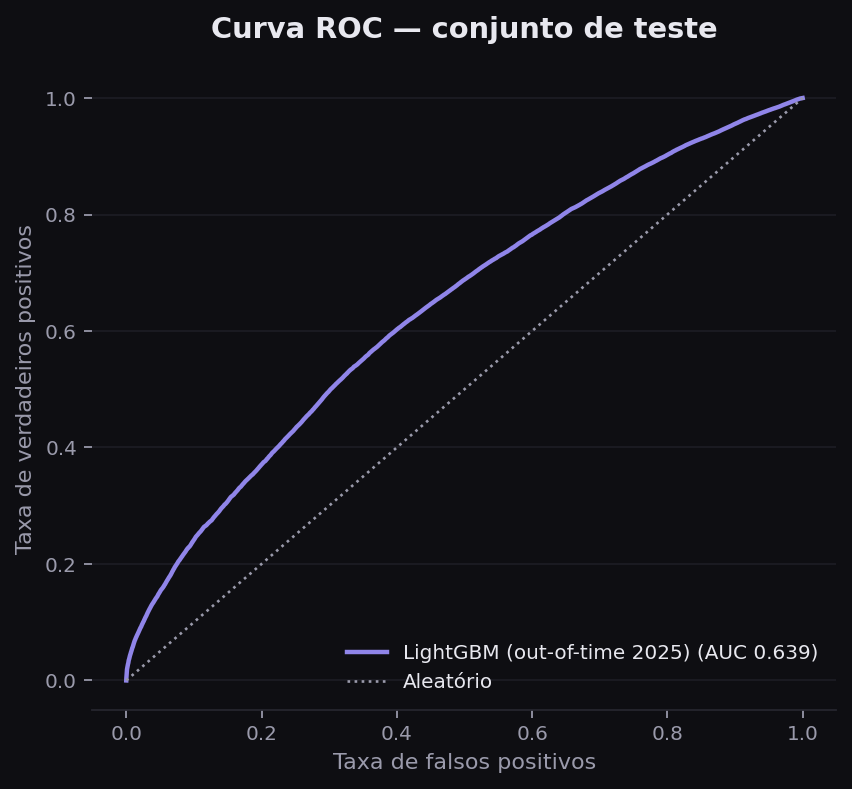

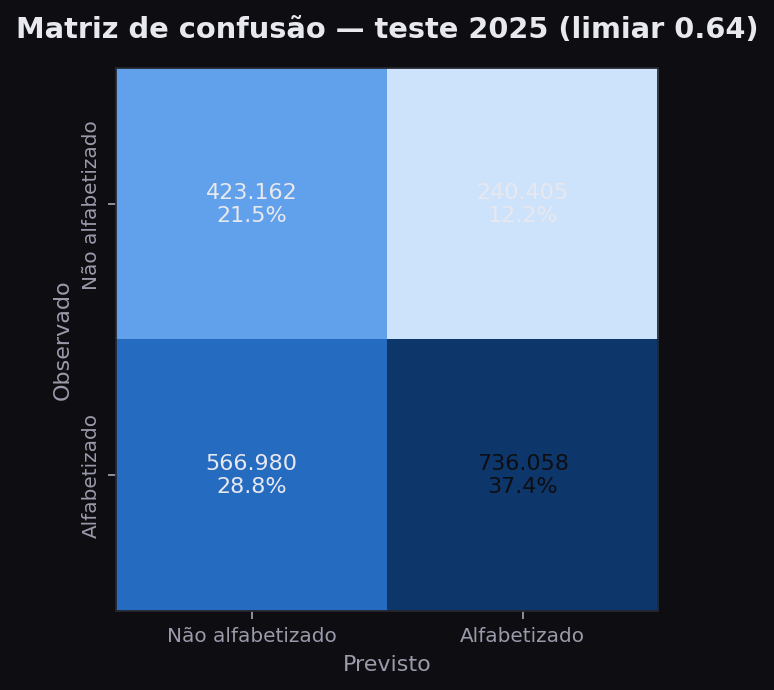

In [10]:
display(Image(filename="../images/07_roc_aluno.png"))
display(Image(filename="../images/08_matriz_confusao_aluno.png"))

### Limiar de decisão

Fixar o corte em 0,5 é uma escolha arbitrária, e aqui os erros custam coisas diferentes: **deixar de
sinalizar uma criança em risco** (falso negativo) significa não enviar reforço a quem precisa;
**sinalizar uma criança que iria bem** custa uma vaga a mais em um programa de apoio. O limiar é
calibrado por acurácia balanceada.

In [11]:
print(f"Limiar padrão (0,50): recall {resultado['teste_out_of_time']['recall']:.3f} | "
      f"acurácia balanceada {resultado['teste_out_of_time']['acuracia_balanceada']:.3f}")
print(f"Limiar calibrado ({resultado['limiar_balanceado']:.2f}): "
      f"recall {resultado['teste_limiar_otimizado']['recall']:.3f} | "
      f"acurácia balanceada {resultado['teste_limiar_otimizado']['acuracia_balanceada']:.3f}")

Limiar padrão (0,50): recall 0.859 | acurácia balanceada 0.563
Limiar calibrado (0.64): recall 0.565 | acurácia balanceada 0.601


### Calibração

Para uso agregado, a **calibração** importa mais que a acurácia: se o modelo diz "70% de chance",
queremos que ~70% daquele grupo realmente se alfabetize. É isso que permite somar probabilidades e
estimar *quantas* crianças estão em risco em um município.

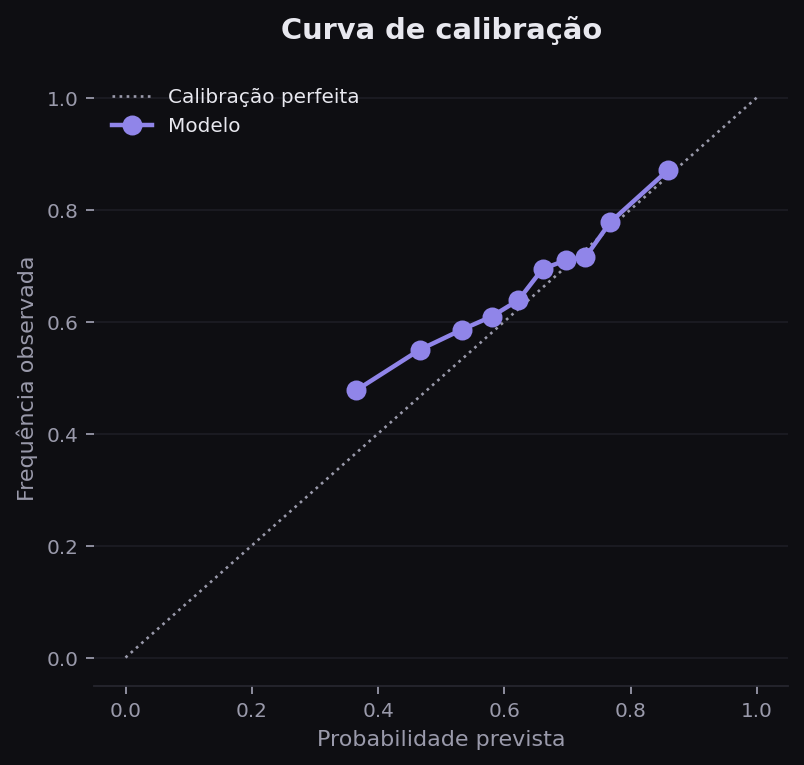

Brier score (quanto menor, melhor): 0.2138


In [12]:
display(Image(filename="../images/09_calibracao_aluno.png"))
print(f"Brier score (quanto menor, melhor): {resultado['teste_out_of_time']['brier']:.4f}")

## 8. Replicabilidade

- `random_state` fixo em toda a pipeline (`config.RANDOM_STATE`);
- pré-processamento e modelo serializados juntos em `models/modelo_aluno.joblib`;
- bases intermediárias reconstruíveis a partir de `data/raw` com um comando;
- separação temporal explícita, sem sorteio dependente de execução.

In [13]:
modelo = joblib.load(config.MODELS_DIR / "modelo_aluno.joblib")
amostra = X_te.head(5)
pd.DataFrame({
    "probabilidade_alfabetizado": modelo.predict_proba(amostra)[:, 1].round(4),
    "observado": y_te.head(5).values,
})

,probabilidade_alfabetizado,observado
0,0.6646,1
1,0.6646,0
2,0.6646,0
3,0.6646,1
4,0.6646,1


Próximo passo: `03_modelagem_municipio.ipynb` — onde o mesmo desenho é aplicado no grão em que o
modelo realmente decide política pública.